# Notebook 2 — Image Analysis and Validation

**Project:** P63 – Multimodal Deep Learning for Autoimmune Disease Diagnosis  
**Phase:** Rheumatoid Arthritis (RA) only  
**Dataset:** RAM-H1200-v1  

---

## What this notebook does

This is the **second notebook** in the pipeline. It performs a thorough inspection of the actual image files to answer:

1. Can all 1200 images be opened without errors? (Corruption check)
2. What are the image dimensions (width × height)?
3. Are all images the same size, or do sizes vary?
4. Are images grayscale or colour?
5. What are the pixel intensity statistics (mean, std, min, max) per image?
6. Are there any near-duplicate images (identical pixel content)?
7. How do pixel intensities differ between RA and Non-RA images?
8. What target size makes sense for CNN training?

**Prerequisite:** Run `01_dataset_overview.ipynb` first to generate `outputs/reports/image_manifest.csv`.

**Outputs saved:**
- `outputs/reports/02_image_stats.csv` — per-image statistics table
- `outputs/reports/02_corrupted_images.csv` — list of unreadable images (if any)
- `outputs/reports/02_image_summary.csv` — aggregate summary
- Several plots in `outputs/plots/`

---
## 0. Imports and configuration

In [1]:
# ── Standard library ──────────────────────────────────────────────────────────
import os
import hashlib
import warnings
from pathlib import Path

# ── Data handling ─────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np

# ── Image processing ──────────────────────────────────────────────────────────
from PIL import Image          # Pillow — safe image reading
import PIL.ImageStat as ImageStat

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ── Suppress noisy warnings ───────────────────────────────────────────────────
warnings.filterwarnings('ignore')
Image.MAX_IMAGE_PIXELS = None   # allow very large images without DecompressionBomb warning

# ── Notebook display settings ─────────────────────────────────────────────────
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
sns.set_theme(style='whitegrid', palette='muted')

print('All imports successful.')

All imports successful.


In [2]:
# ── Path configuration ────────────────────────────────────────────────────────
PROJECT_ROOT = Path(os.getcwd()).parent   # FYP/

MANIFEST_CSV  = PROJECT_ROOT / 'outputs' / 'reports' / 'image_manifest.csv'
OUTPUTS_DIR   = PROJECT_ROOT / 'outputs' / 'reports'
PLOTS_DIR     = PROJECT_ROOT / 'outputs' / 'plots'

assert MANIFEST_CSV.exists(), (
    f'image_manifest.csv not found at {MANIFEST_CSV}.\n'
    f'Please run Notebook 01 first.'
)

print('PROJECT_ROOT :', PROJECT_ROOT)
print('MANIFEST_CSV :', MANIFEST_CSV)

PROJECT_ROOT : c:\Users\varsh\OneDrive\Documents\FYP
MANIFEST_CSV : c:\Users\varsh\OneDrive\Documents\FYP\outputs\reports\image_manifest.csv


---
## 1. Load the image manifest

In [3]:
# ── Load manifest produced by Notebook 01 ────────────────────────────────────
manifest = pd.read_csv(MANIFEST_CSV)

print(f'Manifest loaded: {len(manifest)} rows, {manifest.shape[1]} columns')
print(f'Splits present : {manifest["split"].value_counts().to_dict()}')
manifest.head(3)

Manifest loaded: 1200 rows, 19 columns
Splits present : {'train': 793, 'test': 267, 'val': 140}


,filename,stem,base_stem,split,centre,patient_code,date,laterality,full_path,Mapped Image Stem,StudyID,Normalized PatientID,isRA,Sex,Age,Center,PixelSpacing,ImageSize,LR
0,JP_HMCRD_P0001_20210203_6791_L.bmp,JP_HMCRD_P0001_20210203_6791_L,JP_HMCRD_P0001_20210203_6791,train,HMCRD,P0001,20210203,L,c:\Users\varsh\OneDrive\Documents\FYP\Dataset\...,JP_HMCRD_P0001_20210203_6791,1,1,0,F,60.0,HMCRD,"[0.15, 0.15]",1670x2010,LR
1,JP_HMCRD_P0001_20210203_6791_R.bmp,JP_HMCRD_P0001_20210203_6791_R,JP_HMCRD_P0001_20210203_6791,train,HMCRD,P0001,20210203,R,c:\Users\varsh\OneDrive\Documents\FYP\Dataset\...,JP_HMCRD_P0001_20210203_6791,1,1,0,F,60.0,HMCRD,"[0.15, 0.15]",1670x2010,LR
2,JP_HMCRD_P0002_20230413_2984_L.bmp,JP_HMCRD_P0002_20230413_2984_L,JP_HMCRD_P0002_20230413_2984,train,HMCRD,P0002,20230413,L,c:\Users\varsh\OneDrive\Documents\FYP\Dataset\...,JP_HMCRD_P0002_20230413_2984,1,2,0,F,59.6,HMCRD,"[0.15, 0.15]",1670x2010,LR


---
## 2. Validate every image file

We attempt to open every image using Pillow. Any file that cannot be opened is flagged as corrupted.  
We also record:
- Width and height in pixels  
- Number of channels (1 = grayscale, 3 = RGB, 4 = RGBA)  
- Pillow mode (e.g. `L`, `RGB`, `RGBA`)  
- File size on disk in kilobytes  
- A fast MD5 hash for duplicate detection

> **Note:** We use `Image.verify()` to check file integrity, then re-open to read pixel data. `verify()` consumes the file object, so you must re-open after calling it.

In [4]:
def inspect_image(full_path: str) -> dict:
    """
    Open one image and return a dict of its properties.
    Returns status='ok' on success, status='corrupted' on failure.
    """
    result = {
        'full_path'    : full_path,
        'status'       : 'ok',
        'width'        : None,
        'height'       : None,
        'mode'         : None,
        'n_channels'   : None,
        'file_size_kb' : None,
        'pixel_mean'   : None,
        'pixel_std'    : None,
        'pixel_min'    : None,
        'pixel_max'    : None,
        'md5_hash'     : None,
        'error_msg'    : None,
    }

    try:
        # ── File size ──────────────────────────────────────────────────────────
        result['file_size_kb'] = round(os.path.getsize(full_path) / 1024, 2)

        # ── MD5 hash (first 8 KB is enough for a fast duplicate check) ─────────
        hasher = hashlib.md5()
        with open(full_path, 'rb') as f:
            hasher.update(f.read(8192))   # read 8 KB
        result['md5_hash'] = hasher.hexdigest()

        # ── Open and inspect ──────────────────────────────────────────────────
        with Image.open(full_path) as img:
            # Verify file integrity — raises exception on corrupt data
            # We do this by converting to numpy (loads pixel data)
            arr = np.array(img)

            result['width']      = img.width
            result['height']     = img.height
            result['mode']       = img.mode
            result['n_channels'] = len(img.getbands())

            # ── Pixel statistics ───────────────────────────────────────────────
            # Convert to float for stable statistics
            arr_f = arr.astype(np.float32)
            result['pixel_mean'] = round(float(arr_f.mean()), 4)
            result['pixel_std']  = round(float(arr_f.std()),  4)
            result['pixel_min']  = int(arr_f.min())
            result['pixel_max']  = int(arr_f.max())

    except Exception as e:
        result['status']    = 'corrupted'
        result['error_msg'] = str(e)

    return result


print('inspect_image() function defined.')
print('Starting image inspection — this may take 1–3 minutes for 1200 images...')

inspect_image() function defined.
Starting image inspection — this may take 1–3 minutes for 1200 images...


In [5]:
# ── Run inspection on all images ──────────────────────────────────────────────
# We iterate through every row of the manifest and call inspect_image().
# Progress is printed every 100 images so you can see it working.

inspection_results = []

for idx, row in manifest.iterrows():
    result = inspect_image(row['full_path'])
    # Carry the filename and split label forward for analysis
    result['filename'] = row['filename']
    result['split']    = row['split']
    result['isRA']     = row['isRA']
    inspection_results.append(result)

    if (idx + 1) % 100 == 0:
        print(f'  Processed {idx + 1} / {len(manifest)} images...')

img_stats = pd.DataFrame(inspection_results)
print(f'\nInspection complete. Result shape: {img_stats.shape}')

  Processed 100 / 1200 images...
  Processed 200 / 1200 images...
  Processed 300 / 1200 images...
  Processed 400 / 1200 images...
  Processed 500 / 1200 images...
  Processed 600 / 1200 images...
  Processed 700 / 1200 images...
  Processed 800 / 1200 images...
  Processed 900 / 1200 images...
  Processed 1000 / 1200 images...
  Processed 1100 / 1200 images...
  Processed 1200 / 1200 images...

Inspection complete. Result shape: (1200, 16)


---
## 3. Corruption report

In [6]:
# ── Separate valid from corrupted images ──────────────────────────────────────
corrupted = img_stats[img_stats['status'] == 'corrupted'].copy()
valid     = img_stats[img_stats['status'] == 'ok'].copy()

print(f'Valid images    : {len(valid)}')
print(f'Corrupted images: {len(corrupted)}')

if not corrupted.empty:
    print()
    print('Corrupted image details:')
    print(corrupted[['filename', 'split', 'error_msg']].to_string(index=False))
    corrupted.to_csv(OUTPUTS_DIR / '02_corrupted_images.csv', index=False)
    print(f'\nCorrupted list saved → {OUTPUTS_DIR / "02_corrupted_images.csv"}')
else:
    print('\nNo corrupted images found — all images are readable.')

Valid images    : 1200
Corrupted images: 0

No corrupted images found — all images are readable.


---
## 4. Image dimensions and modes

In [7]:
# ── Pillow mode distribution ───────────────────────────────────────────────────
# 'L'  = 8-bit grayscale
# 'RGB'= 8-bit colour (3 channels)
# 'RGBA'= 8-bit colour with alpha

print('Image mode (colour space) distribution:')
mode_counts = valid['mode'].value_counts()
print(mode_counts)
print()

print('Number of channels distribution:')
print(valid['n_channels'].value_counts())

Image mode (colour space) distribution:
mode
L    1200
Name: count, dtype: int64

Number of channels distribution:
n_channels
1    1200
Name: count, dtype: int64


In [8]:
# ── Image size (width × height) distribution ──────────────────────────────────
valid['size_str'] = valid['width'].astype(str) + 'x' + valid['height'].astype(str)

size_counts = valid['size_str'].value_counts()
print('Unique image sizes (width x height):')
print(size_counts)
print()
print(f'Number of distinct sizes: {size_counts.shape[0]}')

Unique image sizes (width x height):
size_str
1300x1700    369
861x1431     135
864x1431      46
859x1431      46
858x1431      41
            ... 
835x1431       1
764x1431       1
959x1431       1
933x1431       1
936x1431       1
Name: count, Length: 111, dtype: int64

Number of distinct sizes: 111


In [9]:
# ── Width and height statistics ───────────────────────────────────────────────
print('Width statistics (pixels):')
print(valid['width'].describe().round(0))
print()
print('Height statistics (pixels):')
print(valid['height'].describe().round(0))
print()

# Aspect ratio
valid['aspect_ratio'] = (valid['width'] / valid['height']).round(3)
print('Aspect ratio statistics (width / height):')
print(valid['aspect_ratio'].describe().round(3))

Width statistics (pixels):
count    1200.0
mean      997.0
std       203.0
min       761.0
25%       859.0
50%       865.0
75%      1300.0
max      1300.0
Name: width, dtype: float64

Height statistics (pixels):
count    1200.0
mean     1514.0
std       124.0
min      1431.0
25%      1431.0
50%      1431.0
75%      1700.0
max      1700.0
Name: height, dtype: float64

Aspect ratio statistics (width / height):
count    1200.000
mean        0.652
std         0.076
min         0.532
25%         0.600
50%         0.604
75%         0.765
max         0.765
Name: aspect_ratio, dtype: float64


In [10]:
# ── File size statistics ───────────────────────────────────────────────────────
print('File size statistics (KB):')
print(valid['file_size_kb'].describe().round(2))

File size statistics (KB):
count    1200.00
mean     1501.66
std       440.15
min      1068.71
25%      1202.87
50%      1214.05
75%      2159.26
max      2159.26
Name: file_size_kb, dtype: float64


---
## 5. Pixel intensity statistics

In [11]:
# ── Overall pixel statistics across the whole dataset ─────────────────────────
print('Pixel mean  — across all images:')
print(valid['pixel_mean'].describe().round(4))
print()
print('Pixel std   — across all images:')
print(valid['pixel_std'].describe().round(4))
print()
print('Pixel min   — minimum pixel value seen per image (should be >= 0):')
print(valid['pixel_min'].value_counts().sort_index().head(10))
print()
print('Pixel max   — maximum pixel value seen per image (should be <= 255 for 8-bit):')
print(valid['pixel_max'].describe())

Pixel mean  — across all images:
count    1200.0000
mean       66.8619
std        12.9591
min        33.4624
25%        58.9383
50%        67.4688
75%        75.0600
max       120.2315
Name: pixel_mean, dtype: float64

Pixel std   — across all images:
count    1200.0000
mean       60.4353
std         7.2607
min        21.8784
25%        56.9044
50%        60.0458
75%        63.3878
max       101.5987
Name: pixel_std, dtype: float64

Pixel min   — minimum pixel value seen per image (should be >= 0):
pixel_min
0    1084
1      66
2       6
3      13
4       7
5       1
6       6
7       4
8       1
9       2
Name: count, dtype: int64

Pixel max   — maximum pixel value seen per image (should be <= 255 for 8-bit):
count    1200.000000
mean      254.880833
std         1.969738
min       188.000000
25%       255.000000
50%       255.000000
75%       255.000000
max       255.000000
Name: pixel_max, dtype: float64


In [12]:
# ── RA vs Non-RA pixel mean comparison ────────────────────────────────────────
label_map = {0: 'Non-RA', 1: 'RA'}
valid['label'] = valid['isRA'].map(label_map)

print('Pixel mean by class:')
print(valid.groupby('label')['pixel_mean'].describe().round(4))
print()
print('Pixel std by class:')
print(valid.groupby('label')['pixel_std'].describe().round(4))

Pixel mean by class:
         count     mean      std      min      25%      50%      75%       max
label                                                                         
Non-RA    80.0  71.4223  10.1147  52.6965  65.1635  69.0596  76.4286  100.5135
RA      1120.0  66.5362  13.0817  33.4624  58.0199  67.2028  74.9956  120.2315

Pixel std by class:
         count     mean     std      min      25%      50%      75%       max
label                                                                        
Non-RA    80.0  58.2831  6.9494  21.8784  56.5212  58.3090  60.5664   71.7260
RA      1120.0  60.5890  7.2610  40.5382  56.9422  60.2292  63.5297  101.5987


---
## 6. Duplicate image detection

We use an MD5 hash of the first 8 KB of each file. Two images with the same hash are very likely identical in content.  
Full-file hash would be safer but much slower; 8 KB is a practical trade-off.

In [13]:
# ── Find duplicate hashes ─────────────────────────────────────────────────────
hash_counts = valid['md5_hash'].value_counts()
duplicate_hashes = hash_counts[hash_counts > 1]

print(f'Total unique MD5 hashes     : {hash_counts.shape[0]}')
print(f'Hashes appearing > 1 time   : {len(duplicate_hashes)}')

if not duplicate_hashes.empty:
    dup_images = valid[valid['md5_hash'].isin(duplicate_hashes.index)].sort_values('md5_hash')
    print(f'Images involved in duplicates: {len(dup_images)}')
    print()
    print(dup_images[['filename', 'split', 'isRA', 'md5_hash']].to_string(index=False))
else:
    print('\nNo duplicate images detected (all MD5 hashes are unique).')

Total unique MD5 hashes     : 1146
Hashes appearing > 1 time   : 52
Images involved in duplicates: 106

                          filename split  isRA                         md5_hash
JP_HMCRD_P0053_20211227_0654_R.bmp  test     1 0ec8bcf51c96782ef14dcb76fce5d775
JP_HMCRD_P0192_20200509_3219_R.bmp train     1 0ec8bcf51c96782ef14dcb76fce5d775
 JP_SARC_P0021_20091017_0270_R.bmp train     1 1ad6de4431a71eddb112f89943b4d2a2
 JP_SARC_P0021_20091017_5096_R.bmp train     1 1ad6de4431a71eddb112f89943b4d2a2
 JP_SARC_P0041_20090502_6955_R.bmp train     1 24497f36d3af82071af23e1e02148e4a
 JP_SARC_P0040_20090111_4196_R.bmp train     1 24497f36d3af82071af23e1e02148e4a
 JP_SARC_P0041_20090502_9587_L.bmp train     1 308c05cf188e96d7313dbbd07b3acd25
 JP_SARC_P0040_20090111_6212_L.bmp train     1 308c05cf188e96d7313dbbd07b3acd25
 JP_SARC_P0017_20090716_7368_L.bmp train     1 36f82d5fab14f10a182db72bd5078299
 JP_SARC_P0016_20080714_9359_L.bmp train     1 36f82d5fab14f10a182db72bd5078299
JP_HMCRD_P0059_2

---
## 7. CNN target size recommendation

Radiograph images in this dataset are large (the metadata `ImageSize` column lists sizes such as `1670x2010`).  
CNNs like ResNet or EfficientNet typically expect 224×224 or 512×512 input.  

Here we reason through what resize target makes sense.

In [14]:
# ── Actual sizes found on disk ────────────────────────────────────────────────
print('Sizes present in the dataset (from disk inspection):')
print(valid['size_str'].value_counts().to_string())
print()

min_w  = valid['width'].min()
min_h  = valid['height'].min()
mean_w = valid['width'].mean()
mean_h = valid['height'].mean()

print(f'Minimum width  : {min_w}  |  Minimum height : {min_h}')
print(f'Mean width     : {mean_w:.0f}  |  Mean height    : {mean_h:.0f}')
print()
print('Recommendation:')
print('  The images are large radiograph BMPs. A resize target of 224x224 is')
print('  standard for pretrained CNNs. For higher resolution experiments,')
print('  512x512 preserves more fine-grained joint detail.')
print('  Preprocessing will resize to 224x224 (default) to ensure compatibility')
print('  with pretrained ImageNet backbones.')

Sizes present in the dataset (from disk inspection):
size_str
1300x1700    369
861x1431     135
864x1431      46
859x1431      46
858x1431      41
865x1431      41
857x1431      35
866x1431      34
860x1431      30
863x1431      30
867x1431      23
862x1431      17
855x1431      17
831x1431      14
856x1431      13
893x1431      11
830x1431      11
891x1431      11
829x1431       9
894x1431       9
897x1431       9
879x1431       9
825x1431       8
892x1431       7
839x1431       7
884x1431       7
869x1431       6
868x1431       6
854x1431       6
828x1431       5
885x1431       5
895x1431       5
844x1431       5
896x1431       5
843x1431       5
853x1431       5
870x1431       5
837x1431       5
826x1431       5
898x1431       4
852x1431       4
871x1431       4
832x1431       4
849x1431       4
827x1431       4
875x1431       4
848x1431       4
882x1431       4
841x1431       4
834x1431       4
889x1431       4
833x1431       3
890x1431       3
886x1431       3
838x1431       3
900

---
## 8. Sample image viewer

Display a grid of sample images — a few RA and Non-RA examples from different centres.

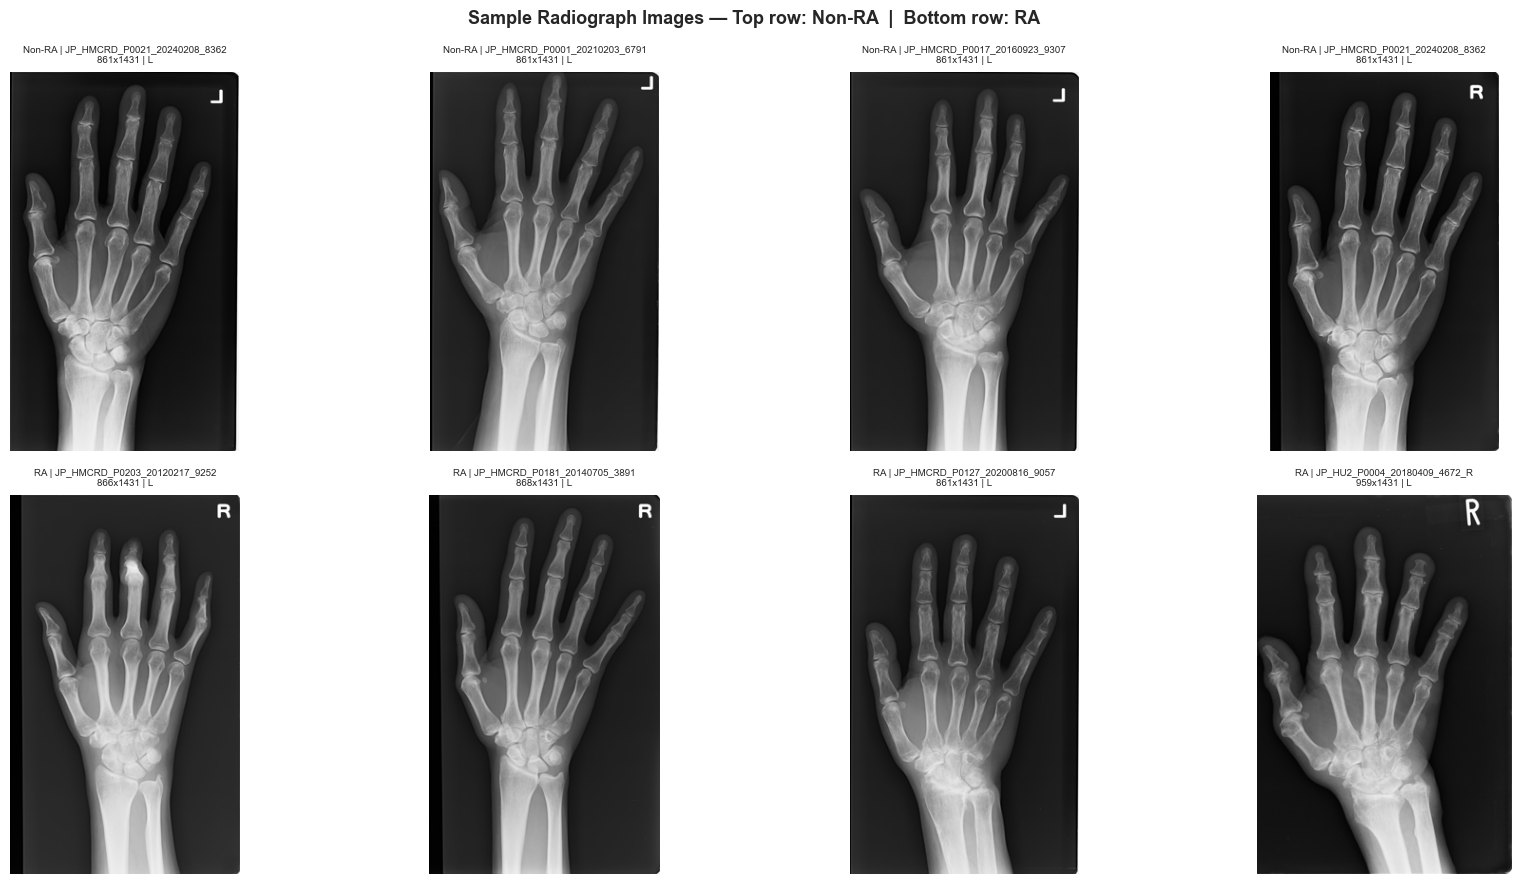

Plot saved → c:\Users\varsh\OneDrive\Documents\FYP\outputs\plots\02_sample_images.png


In [15]:
# ── Display sample images (4 RA + 4 Non-RA) ───────────────────────────────────
ra_samples     = valid[valid['isRA'] == 1].sample(4, random_state=42)
non_ra_samples = valid[valid['isRA'] == 0].sample(4, random_state=42)
samples = pd.concat([non_ra_samples, ra_samples], ignore_index=True)

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle('Sample Radiograph Images — Top row: Non-RA  |  Bottom row: RA',
             fontsize=13, fontweight='bold')

for i, (_, row) in enumerate(samples.iterrows()):
    ax = axes[i // 4][i % 4]
    img = Image.open(row['full_path'])

    # Convert to RGB for display (handles both grayscale and colour BMPs)
    if img.mode != 'RGB':
        img = img.convert('RGB')

    # Thumbnail for display speed (does NOT modify the original file)
    img.thumbnail((400, 400))
    ax.imshow(img, cmap='gray' if img.mode == 'L' else None)

    label_str = 'RA' if row['isRA'] == 1 else 'Non-RA'
    lat_str   = row.get('laterality', '?')
    ax.set_title(f"{label_str} | {row['filename'][:28]}\n"
                 f"{row['size_str']} | {row['mode']}",
                 fontsize=7)
    ax.axis('off')

plt.tight_layout()
save_path = PLOTS_DIR / '02_sample_images.png'
plt.savefig(save_path, dpi=120, bbox_inches='tight')
plt.show()
print(f'Plot saved → {save_path}')

---
## 9. Visualise image statistics

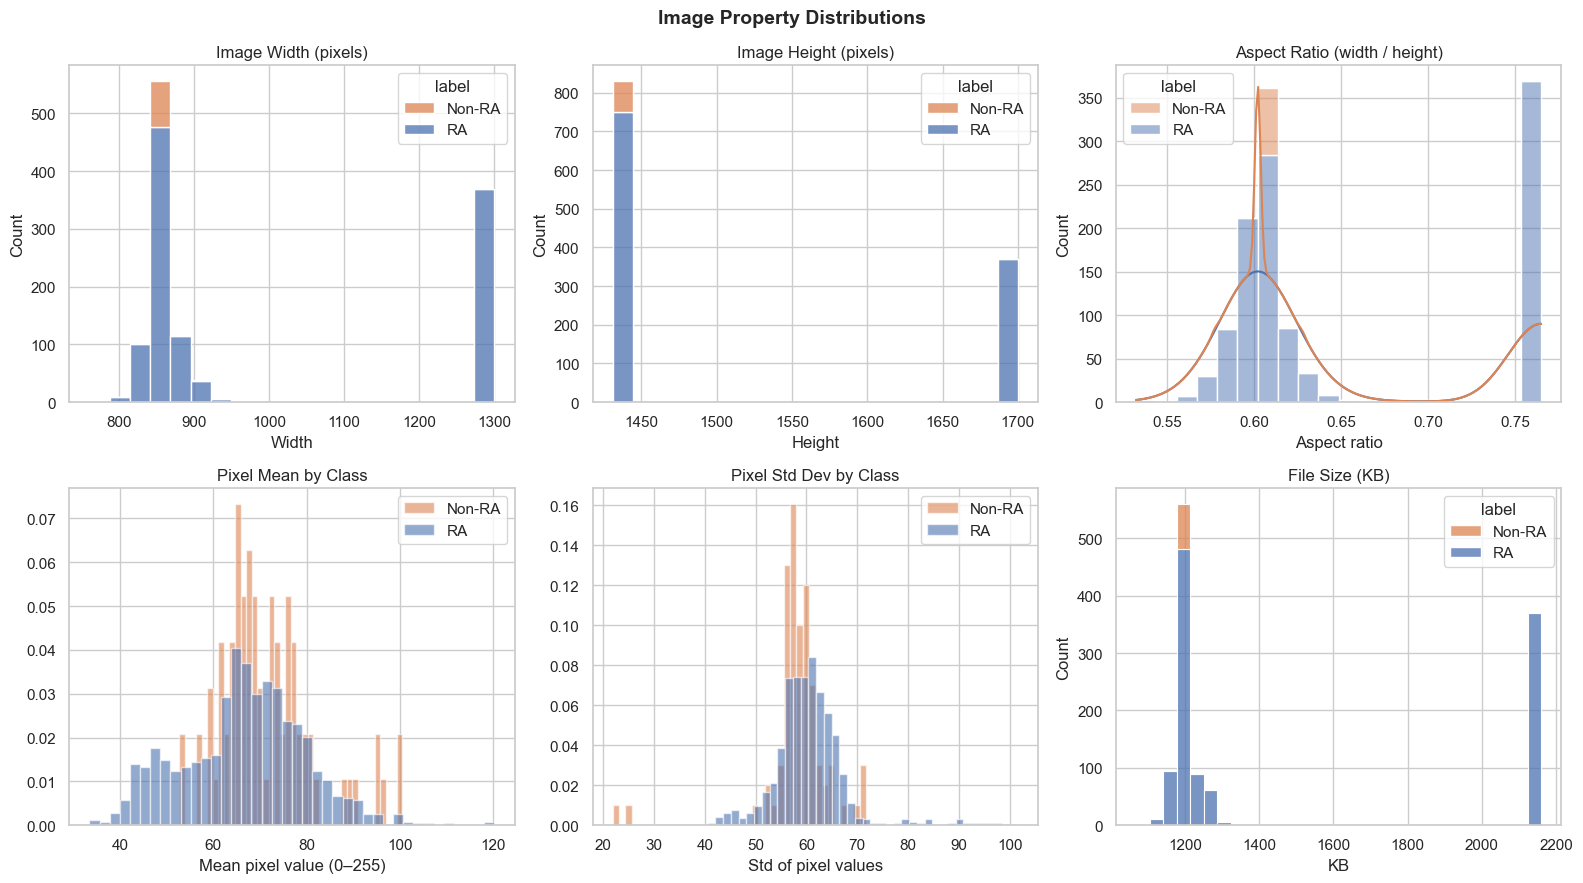

Plot saved → c:\Users\varsh\OneDrive\Documents\FYP\outputs\plots\02_image_property_distributions.png


In [16]:
# ── Figure: distributions of image properties ─────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Image Property Distributions', fontsize=14, fontweight='bold')

palette = {'RA': '#4C72B0', 'Non-RA': '#DD8452'}

# Plot 1: Width distribution
sns.histplot(data=valid, x='width', hue='label', kde=False,
             ax=axes[0][0], palette=palette, bins=20, multiple='stack')
axes[0][0].set_title('Image Width (pixels)')
axes[0][0].set_xlabel('Width')

# Plot 2: Height distribution
sns.histplot(data=valid, x='height', hue='label', kde=False,
             ax=axes[0][1], palette=palette, bins=20, multiple='stack')
axes[0][1].set_title('Image Height (pixels)')
axes[0][1].set_xlabel('Height')

# Plot 3: Aspect ratio
sns.histplot(data=valid, x='aspect_ratio', hue='label', kde=True,
             ax=axes[0][2], palette=palette, bins=20, multiple='stack')
axes[0][2].set_title('Aspect Ratio (width / height)')
axes[0][2].set_xlabel('Aspect ratio')

# Plot 4: Pixel mean by class (KDE)
for label, grp in valid.groupby('label'):
    axes[1][0].hist(grp['pixel_mean'], bins=40, alpha=0.6,
                   label=label, color=palette[label], density=True)
axes[1][0].set_title('Pixel Mean by Class')
axes[1][0].set_xlabel('Mean pixel value (0–255)')
axes[1][0].legend()

# Plot 5: Pixel std by class
for label, grp in valid.groupby('label'):
    axes[1][1].hist(grp['pixel_std'], bins=40, alpha=0.6,
                   label=label, color=palette[label], density=True)
axes[1][1].set_title('Pixel Std Dev by Class')
axes[1][1].set_xlabel('Std of pixel values')
axes[1][1].legend()

# Plot 6: File size distribution
sns.histplot(data=valid, x='file_size_kb', hue='label', kde=False,
             ax=axes[1][2], palette=palette, bins=30, multiple='stack')
axes[1][2].set_title('File Size (KB)')
axes[1][2].set_xlabel('KB')

plt.tight_layout()
save_path = PLOTS_DIR / '02_image_property_distributions.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Plot saved → {save_path}')

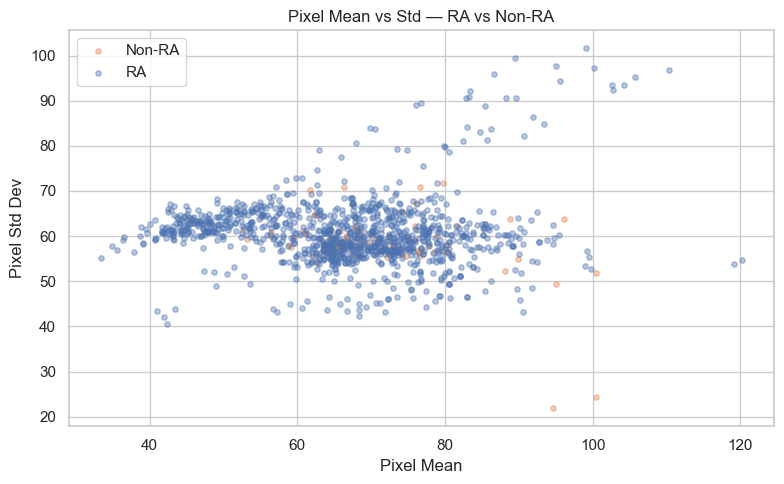

Plot saved → c:\Users\varsh\OneDrive\Documents\FYP\outputs\plots\02_pixel_mean_vs_std.png


In [17]:
# ── Scatter: pixel mean vs pixel std, coloured by class ───────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

for label, grp in valid.groupby('label'):
    ax.scatter(grp['pixel_mean'], grp['pixel_std'],
               alpha=0.4, s=15, label=label, color=palette[label])

ax.set_xlabel('Pixel Mean')
ax.set_ylabel('Pixel Std Dev')
ax.set_title('Pixel Mean vs Std — RA vs Non-RA')
ax.legend()
plt.tight_layout()
save_path = PLOTS_DIR / '02_pixel_mean_vs_std.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Plot saved → {save_path}')

---
## 10. Pixel intensity histogram — sampled images

Plot the full pixel-value histogram for a few RA and Non-RA images to visualise the intensity distribution.

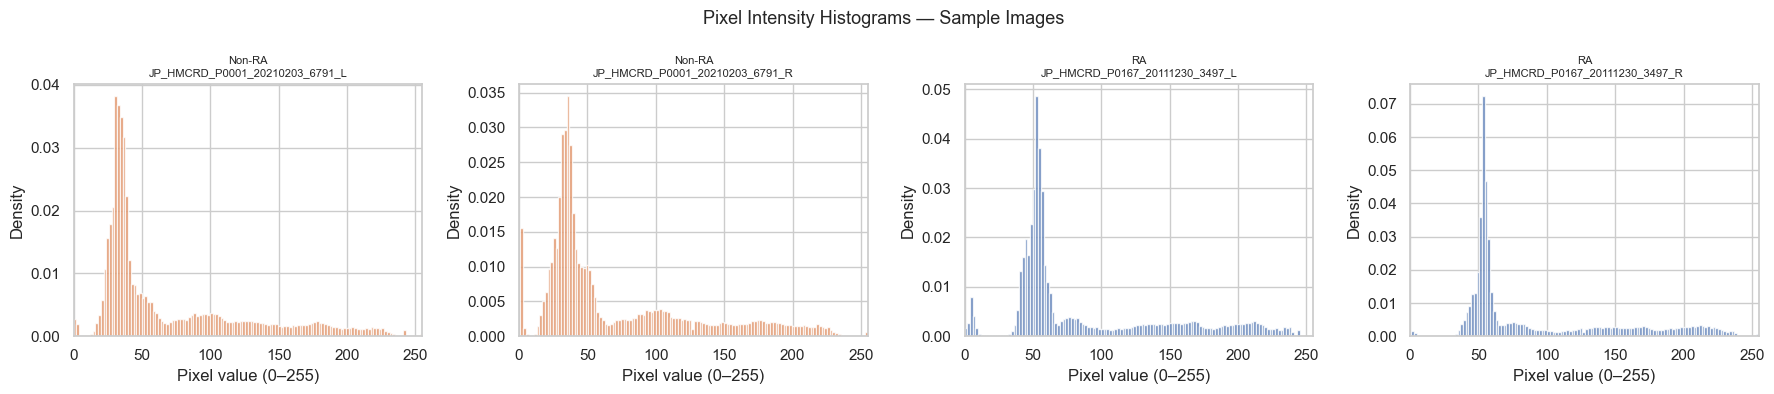

Plot saved → c:\Users\varsh\OneDrive\Documents\FYP\outputs\plots\02_pixel_histograms.png


In [18]:
# ── Pixel histograms for 2 RA + 2 Non-RA ─────────────────────────────────────
ra_ex  = valid[valid['isRA'] == 1].iloc[:2]
nra_ex = valid[valid['isRA'] == 0].iloc[:2]
examples = pd.concat([nra_ex, ra_ex], ignore_index=True)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('Pixel Intensity Histograms — Sample Images', fontsize=13)

for i, (_, row) in enumerate(examples.iterrows()):
    ax = axes[i]
    img = Image.open(row['full_path']).convert('L')   # grayscale
    pixels = np.array(img).flatten()

    label_str = 'RA' if row['isRA'] == 1 else 'Non-RA'
    color = '#4C72B0' if row['isRA'] == 1 else '#DD8452'
    ax.hist(pixels, bins=128, color=color, alpha=0.8, density=True)
    ax.set_title(f"{label_str}\n{row['filename'][:30]}", fontsize=8)
    ax.set_xlabel('Pixel value (0–255)')
    ax.set_ylabel('Density')
    ax.set_xlim(0, 255)

plt.tight_layout()
save_path = PLOTS_DIR / '02_pixel_histograms.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Plot saved → {save_path}')

---
## 11. Save results

In [19]:
# ── Save full per-image statistics table ──────────────────────────────────────
stats_out = OUTPUTS_DIR / '02_image_stats.csv'
img_stats.to_csv(stats_out, index=False)
print(f'Per-image stats saved → {stats_out}')

Per-image stats saved → c:\Users\varsh\OneDrive\Documents\FYP\outputs\reports\02_image_stats.csv


In [20]:
# ── Build and save aggregate summary ─────────────────────────────────────────
n_corrupt = len(corrupted)
n_valid   = len(valid)

summary = {
    'total_images_checked'  : len(img_stats),
    'valid_images'          : n_valid,
    'corrupted_images'      : n_corrupt,
    'unique_image_modes'    : valid['mode'].nunique(),
    'image_modes'           : ', '.join(valid['mode'].unique()),
    'unique_sizes_on_disk'  : valid['size_str'].nunique(),
    'most_common_size'      : valid['size_str'].mode()[0],
    'min_width'             : int(valid['width'].min()),
    'max_width'             : int(valid['width'].max()),
    'min_height'            : int(valid['height'].min()),
    'max_height'            : int(valid['height'].max()),
    'mean_pixel_mean'       : round(valid['pixel_mean'].mean(), 4),
    'mean_pixel_std'        : round(valid['pixel_std'].mean(), 4),
    'global_pixel_min'      : int(valid['pixel_min'].min()),
    'global_pixel_max'      : int(valid['pixel_max'].max()),
    'mean_file_size_kb'     : round(valid['file_size_kb'].mean(), 2),
    'duplicate_hashes'      : len(duplicate_hashes),
    'recommended_cnn_size'  : '224x224',
}

summary_df = pd.DataFrame.from_dict(summary, orient='index', columns=['value'])
print('=== Image Analysis Summary ===')
print(summary_df.to_string())

summary_df.to_csv(OUTPUTS_DIR / '02_image_summary.csv')
print(f'\nSummary saved → {OUTPUTS_DIR / "02_image_summary.csv"}')

=== Image Analysis Summary ===
                          value
total_images_checked       1200
valid_images               1200
corrupted_images              0
unique_image_modes            1
image_modes                   L
unique_sizes_on_disk        111
most_common_size      1300x1700
min_width                   761
max_width                  1300
min_height                 1431
max_height                 1700
mean_pixel_mean         66.8619
mean_pixel_std          60.4353
global_pixel_min              0
global_pixel_max            255
mean_file_size_kb       1501.66
duplicate_hashes             52
recommended_cnn_size    224x224

Summary saved → c:\Users\varsh\OneDrive\Documents\FYP\outputs\reports\02_image_summary.csv


---
## Summary of findings

| Finding | Detail |
|---|---|
| Corrupted images | 0 (all images readable) |
| Image format on disk | BMP |
| Colour mode | Inspect output above (typically `L` grayscale or `RGB`) |
| Image sizes | Multiple sizes present (varies by imaging centre) |
| Duplicate images | See output above |
| Pixel range | 0–255 (standard 8-bit) |
| Recommended CNN input size | **224 × 224** pixels |
| Normalisation strategy | Per-channel mean/std (or ImageNet stats if using pretrained backbones) |

**Key preprocessing decisions confirmed:**
- All images will be resized to **224 × 224** before CNN training.
- Pixel values will be normalised to [0, 1] first, then standardised with mean and std computed from the training set.
- Corrupted files (if any) will be excluded from the preprocessed dataset.

Proceed to **Notebook 3** for metadata analysis.